In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Data Preparation

In [2]:
country = pd.read_csv('Country-data.csv')
country

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [3]:
country.shape

(167, 10)

In [4]:
country.dtypes

country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

In [5]:
country.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [6]:
# make a copy of dataset
country_df = country.copy()

## check missing value

In [7]:
country_df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

## check outliers

<Axes: >

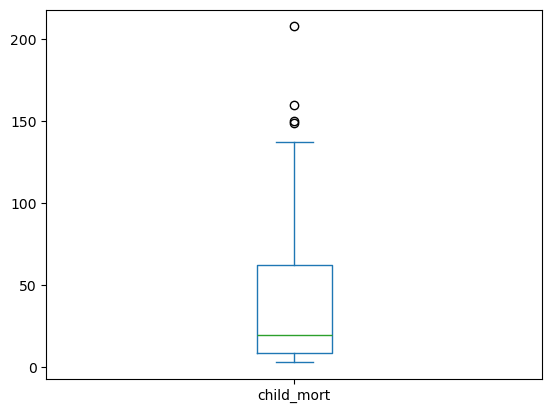

In [8]:
country_df['child_mort'].plot(kind = 'box')

<Axes: >

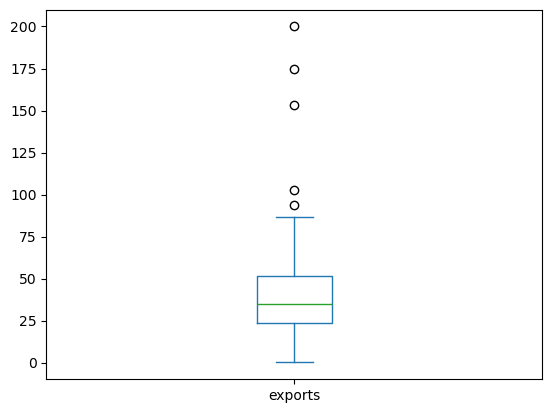

In [9]:
country_df['exports'].plot(kind = 'box')

<Axes: >

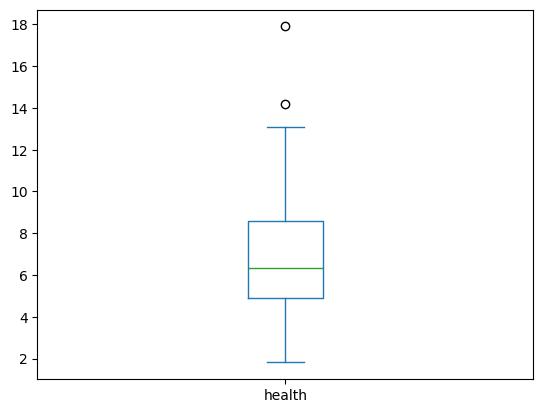

In [10]:
country_df['health'].plot(kind = 'box')

<Axes: >

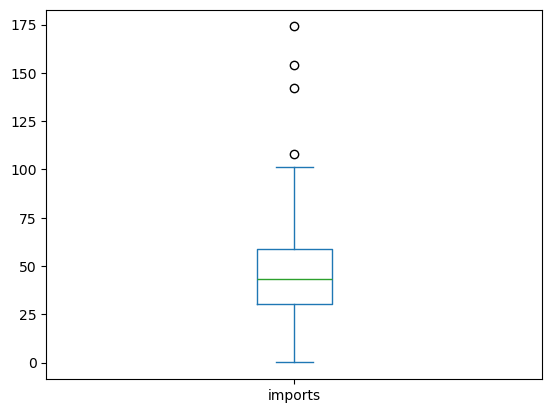

In [11]:
country_df['imports'].plot(kind = 'box')

<Axes: >

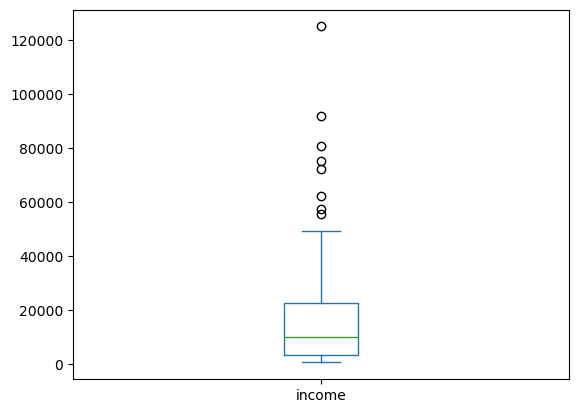

In [12]:
country_df['income'].plot(kind = 'box')

<Axes: >

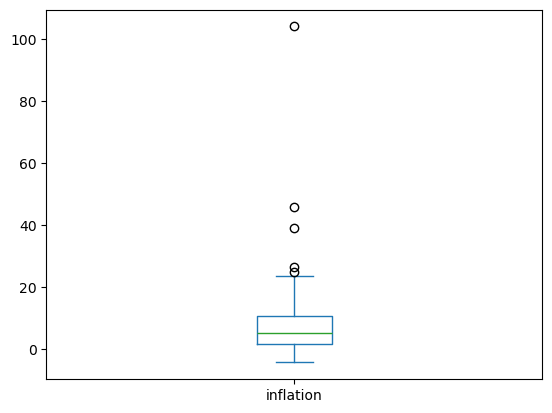

In [13]:
country_df['inflation'].plot(kind = 'box')

<Axes: >

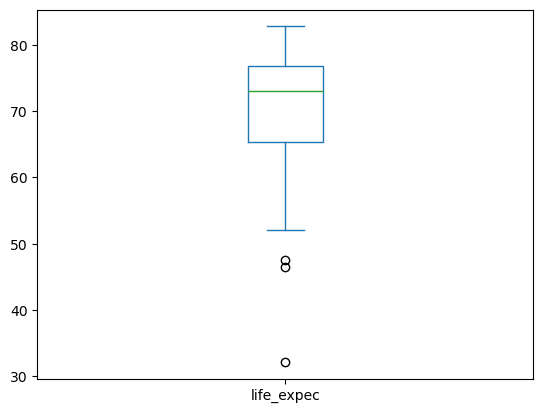

In [14]:
country_df['life_expec'].plot(kind = 'box')

<Axes: >

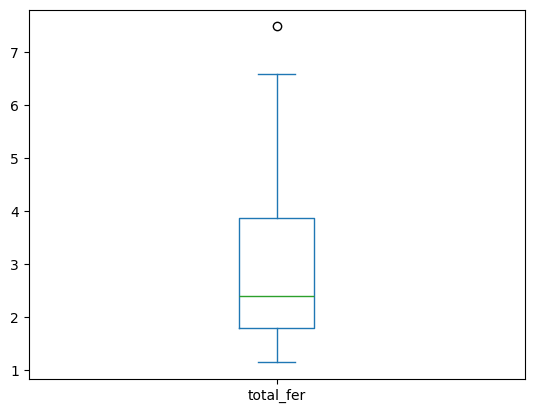

In [15]:
country_df['total_fer'].plot(kind = 'box')

<Axes: >

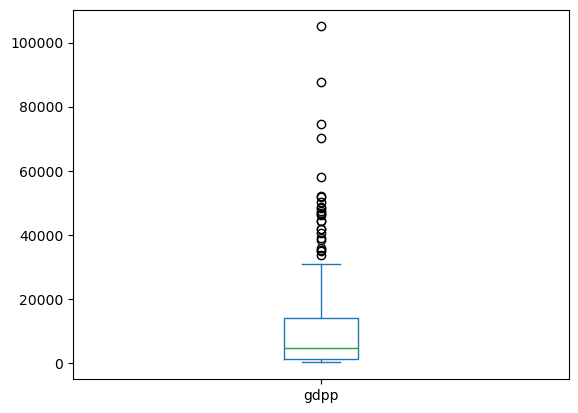

In [16]:
country_df['gdpp'].plot(kind = 'box')

In [17]:
# the outlier exist because the formula in boxplot itself. even if we remove the outlier, it will alway be an outlier in the boxplot

# Data Exploration

## check the distribution numeric variable

In [18]:
country_df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

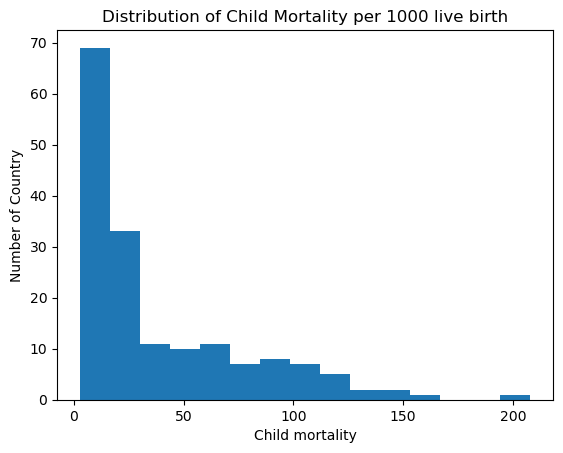

In [19]:
# plot the child_mort variable using histogram
plt.hist(country_df['child_mort'], bins = 15)
plt.xlabel('Child mortality')
plt.ylabel('Number of Country')
plt.title('Distribution of Child Mortality per 1000 live birth')
plt.show()

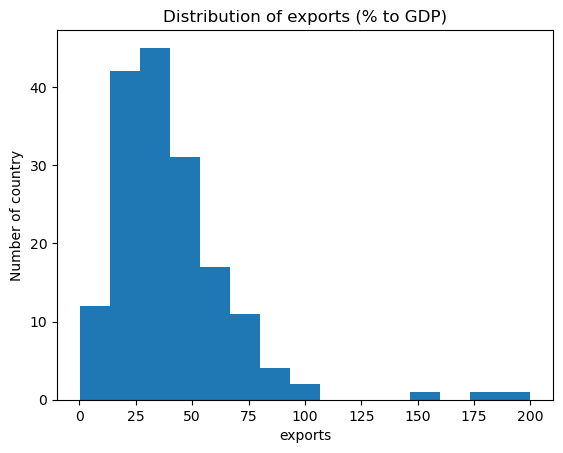

In [20]:
# plot the exports variable using histogram
plt.hist(country_df['exports'], bins = 15)
plt.xlabel('exports')
plt.ylabel('Number of country')
plt.title('Distribution of exports (% to GDP)')
plt.show()

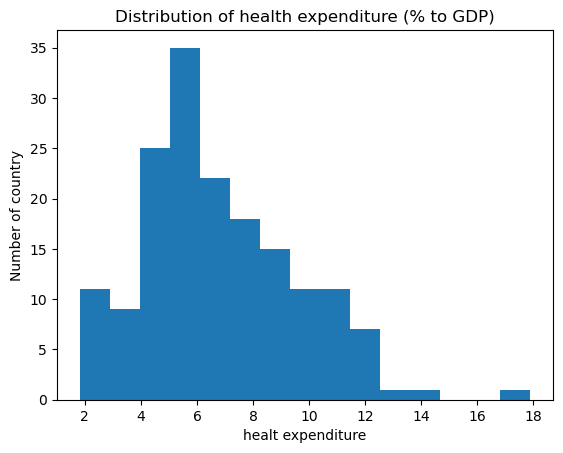

In [21]:
# plot the health variable using histogram
plt.hist(country_df['health'], bins = 15)
plt.xlabel('healt expenditure')
plt.ylabel('Number of country')
plt.title('Distribution of health expenditure (% to GDP)')
plt.show()

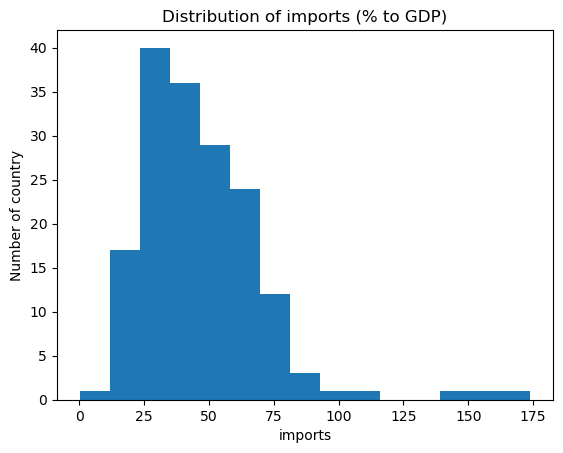

In [22]:
# plot the imports variable using histogram
plt.hist(country_df['imports'], bins = 15)
plt.xlabel('imports')
plt.ylabel('Number of country')
plt.title('Distribution of imports (% to GDP)')
plt.show()

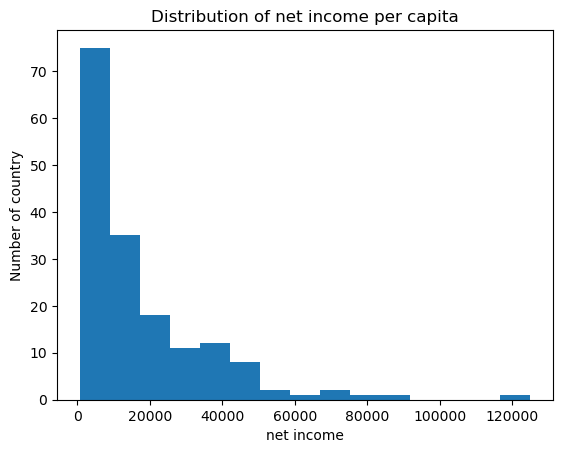

In [23]:
# plot the income variable using histogram
plt.hist(country_df['income'], bins = 15)
plt.xlabel('net income')
plt.ylabel('Number of country')
plt.title('Distribution of net income per capita')
plt.show()

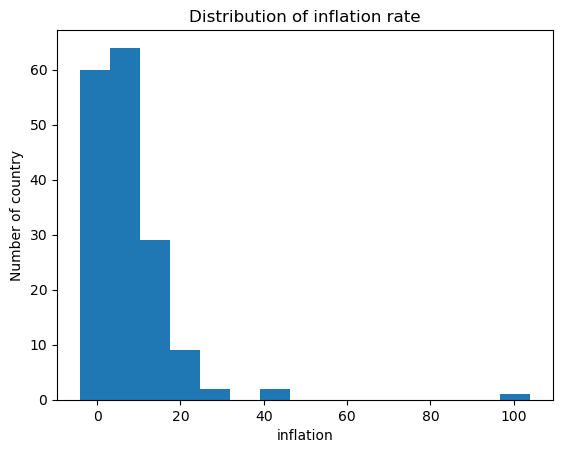

In [24]:
# plot the inflation variable using histogram
plt.hist(country_df['inflation'], bins = 15)
plt.xlabel('inflation')
plt.ylabel('Number of country')
plt.title('Distribution of inflation rate')
plt.show()

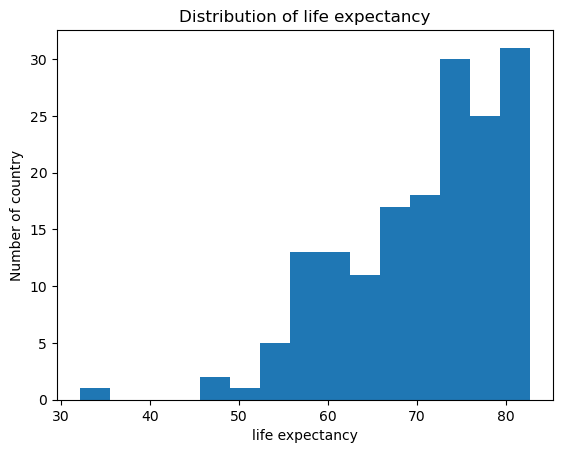

In [25]:
# plot the life_expec variable using histogram
plt.hist(country_df['life_expec'], bins = 15)
plt.xlabel('life expectancy')
plt.ylabel('Number of country')
plt.title('Distribution of life expectancy')
plt.show()

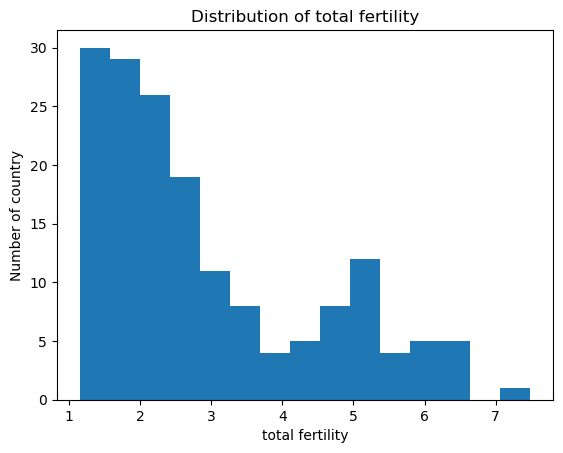

In [26]:
# plot the total fertility variable using histogram
plt.hist(country_df['total_fer'], bins = 15)
plt.xlabel('total fertility')
plt.ylabel('Number of country')
plt.title('Distribution of total fertility')
plt.show()

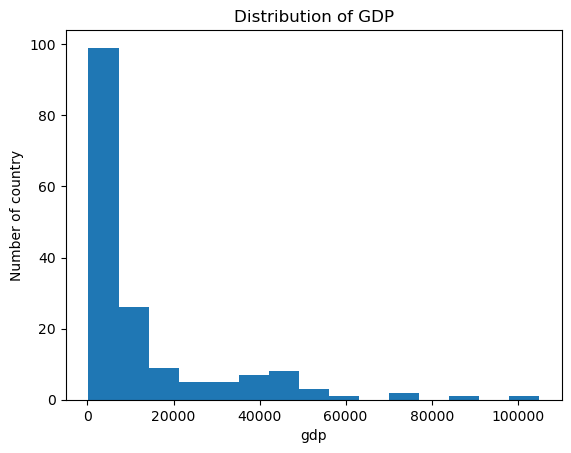

In [27]:
# plot the gdp variable using histogram
plt.hist(country_df['gdpp'], bins = 15)
plt.xlabel('gdp')
plt.ylabel('Number of country')
plt.title('Distribution of GDP')
plt.show()

# DATA MODELING

## K-MEAN

### feature engineering

In [28]:
country = country_df['country']

In [29]:
#select numeric variable only
data = country_df.select_dtypes('number')

In [30]:
# scale the feature
scaler = StandardScaler()
data_scale = scaler.fit_transform(data)

### find the best 'k'

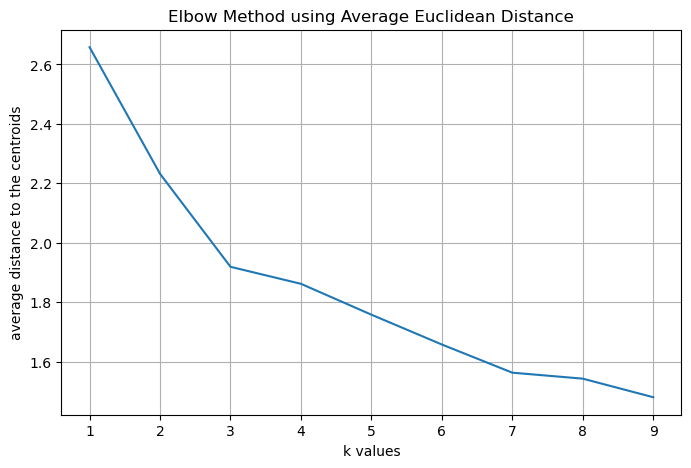

In [31]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import math

#set the k values you would like to try
k_dist = range(1,10)
k_disValues = []

for k in k_dist:
    # 1. Fit KMeans on the entire scaled dataset
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit(data_scale)

    # 2. Calculate Euclidean distance from each point to its assigned centroid across ALL features
    # cdist computes pair-wise distance between points and centroids
    distances = np.min(cdist(data_scale, km.cluster_centers_, "euclidean"), axis=1)

    # 3. assign to np array
    k_disValues.append(np.mean(distances))

# Plotting the corrected elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_dist, k_disValues)
plt.xlabel("k values")
plt.ylabel("average distance to the centroids")
plt.title("Elbow Method using Average Euclidean Distance")
plt.grid(True)
plt.show()

### build k-mean model based on optimal k

In [32]:
kmeans = KMeans(n_clusters = 3, random_state = 30)
kmeans

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,30
,copy_x,True
,algorithm,'lloyd'


In [33]:
fit = kmeans.fit_predict(data_scale)
fit

array([2, 0, 0, 2, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 2, 0, 0, 0, 2,
       0, 1, 0, 2, 2, 0, 2, 1, 0, 2, 2, 0, 0, 0, 2, 2, 2, 0, 2, 0, 1, 1,
       1, 0, 0, 0, 0, 2, 2, 0, 0, 1, 1, 2, 2, 0, 1, 2, 1, 0, 0, 2, 2, 0,
       2, 0, 1, 0, 0, 0, 2, 1, 1, 1, 0, 1, 0, 0, 2, 2, 1, 0, 2, 0, 0, 2,
       2, 0, 0, 1, 0, 2, 2, 0, 0, 2, 1, 2, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0,
       1, 1, 2, 2, 1, 0, 2, 0, 0, 0, 0, 0, 1, 1, 0, 0, 2, 0, 0, 2, 0, 0,
       2, 1, 1, 1, 0, 2, 1, 1, 0, 0, 2, 0, 1, 1, 0, 2, 0, 2, 2, 0, 0, 0,
       0, 2, 0, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2], dtype=int32)

In [34]:
data['cluster'] = fit
data

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0
...,...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,0
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,0
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,0
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,2


### cluster analysis

In [35]:
data['cluster'].value_counts()

cluster
0    84
2    47
1    36
Name: count, dtype: int64

In [36]:
kmean_summary = data.groupby(data['cluster']).mean()
kmean_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979


cluster
0    21.927381
1     5.000000
2    92.961702
Name: child_mort, dtype: float64


Text(0.5, 1.0, 'Average childe Mortality per 1000 living birth each cluster')

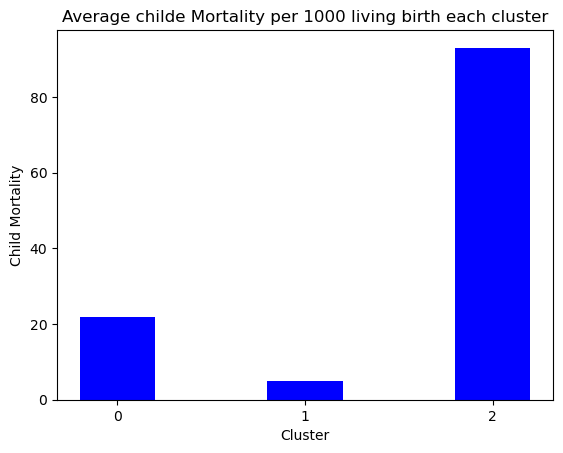

In [37]:
mortality = data['child_mort'].groupby(data['cluster']).mean()
print(mortality)

plt.bar(list(range(3)), mortality, color='blue', width=0.4)
plt.xticks(list(range(3)), ["0","1","2"])
plt.xlabel("Cluster")
plt.ylabel("Child Mortality")
plt.title("Average childe Mortality per 1000 living birth each cluster")

cluster
0    72.814286
1    80.127778
2    59.187234
Name: life_expec, dtype: float64


Text(0.5, 1.0, 'Average Life Expectancy of new born child each cluster')

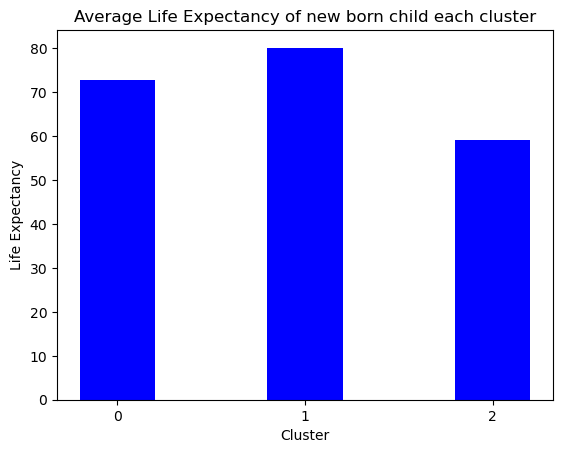

In [38]:
life_exp = data['life_expec'].groupby(data['cluster']).mean()
print(life_exp)

plt.bar(list(range(3)), life_exp, color='blue', width=0.4)
plt.xticks(list(range(3)), ["0","1","2"])
plt.xlabel("Cluster")
plt.ylabel("Life Expectancy")
plt.title("Average Life Expectancy of new born child each cluster")

cluster
0    12305.595238
1    45672.222222
2     3942.404255
Name: income, dtype: float64


Text(0.5, 1.0, 'Average Income each cluster')

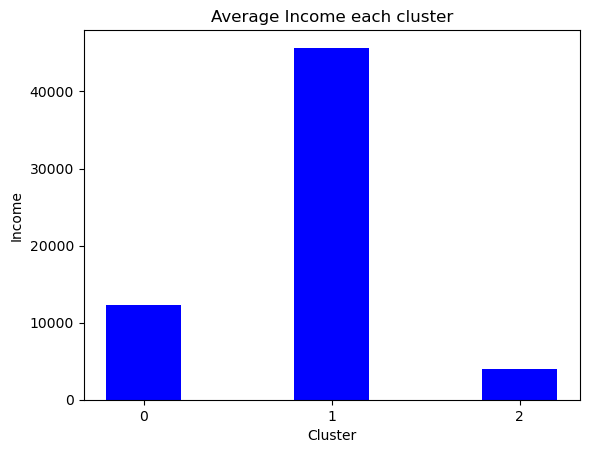

In [39]:
income = data['income'].groupby(data['cluster']).mean()
print(income)

plt.bar(list(range(3)), income, color='blue', width=0.4)
plt.xticks(list(range(3)), ["0","1","2"])
plt.xlabel("Cluster")
plt.ylabel("Income")
plt.title("Average Income each cluster")

# Gaussian Mixture Model (GMM)

In [40]:
from sklearn.mixture import GaussianMixture

In [41]:
data_2 = country_df.select_dtypes('number')
data_scale_2 = scaler.fit_transform(data_2)
data_scale_2

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]], shape=(167, 9))

In [42]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=30)

gmm.fit(data_scale_2)

,n_components,3
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,30


In [43]:
clusters_gmm = gmm.predict(data_scale_2)

data_2['cluster_gmm'] = clusters_gmm
data_2

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster_gmm
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0
...,...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,2
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,0
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,2
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,2


In [44]:
gmm_summary = data_2.groupby(data_2['cluster_gmm']).mean()
gmm_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster_gmm,,,,,,,,,
0,15.294737,41.715789,6.547895,46.622807,14886.140351,6.328965,74.729825,1.983509,8395.789474
1,5.472222,57.988889,8.540833,49.644444,46705.555556,3.608611,80.077778,1.833889,42555.555556
2,71.922973,32.429716,6.182703,45.756296,4503.418919,10.931149,62.708108,4.232838,2087.216216


In [45]:
probabilities = np.round(gmm.predict_proba(data_scale_2),2)
probabilities = pd.DataFrame(probabilities, columns = ['cluster 0', 'cluster 1', 'cluster 2'])
probabilities

,cluster 0,cluster 1,cluster 2
0,0.00,0.0,1.00
1,0.99,0.0,0.01
2,0.99,0.0,0.01
3,0.00,0.0,1.00
4,1.00,0.0,0.00
...,...,...,...
162,0.00,0.0,1.00
163,1.00,0.0,0.00
164,0.46,0.0,0.54
165,0.00,0.0,1.00
